# `Guitarset` Dataset EDA

In [2]:
import numpy as np
import mirdata
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio

## Overview

In [3]:
gs = mirdata.initialize("guitarset")
if gs.validate():
    print("Guitarset successfully initialized.")

100%|██████████| 360/360 [00:21<00:00, 16.80it/s]


Guitarset successfully initialized.


In [4]:
# How many tracks?
print(f"Total Track Count: {len(gs.track_ids)} tracks\n")

# Inspect First Track
test_track_id = gs.track_ids[0]
test_track = gs.load_tracks()[test_track_id]
print(f"Track: {test_track_id}")

# load with librosa
y, sr = librosa.load(test_track.audio_mic_path, sr=None)
print(f"Sample rate: {sr} Hz")

Total Track Count: 360 tracks

Track: 00_BN1-129-Eb_comp
Sample rate: 44100 Hz


In [5]:
# Generate playable audio
Audio(data=y, rate=sr)

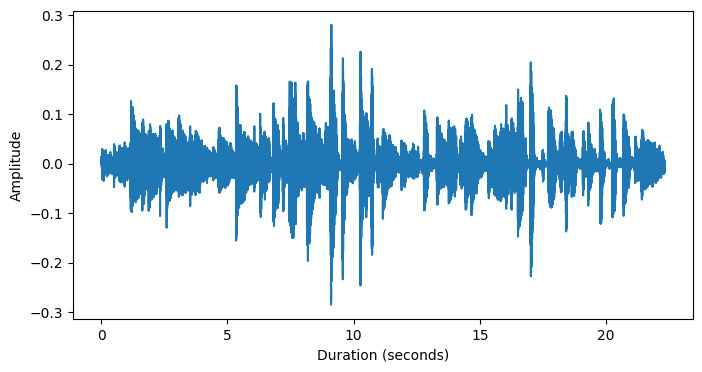

In [6]:
# plot audio
fig, ax = plt.subplots(figsize=(8, 4))
duration = np.arange(len(y)) / sr
ax.plot(duration, y)
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Amplitude")

plt.show()

## Chord Structure

In [7]:
# get chord information
chords_leadsheet = test_track.leadsheet_chords
chords_inferred = test_track.inferred_chords
print("-- Chord From Lead Sheet\nDuration\tChord")
for interval, written in zip(chords_leadsheet.intervals, chords_leadsheet.labels):
    start_time = interval[0]
    end_time = interval[1]
    print(f"{start_time:.2f}-{end_time:.2f}\t{written}")

print("\n-- Chord Inferred\nDuration\tChord")
for interval, inferred in zip(chords_leadsheet.intervals, chords_inferred.labels):
    start_time = interval[0]
    end_time = interval[1]
    print(f"{start_time:.2f}-{end_time:.2f}\t{inferred}")

-- Chord From Lead Sheet
Duration	Chord
0.00-7.44	D#:maj
7.44-11.16	G#:maj
11.16-14.88	D#:maj
14.88-16.74	A#:maj
16.74-18.60	G#:maj
18.60-22.32	D#:maj

-- Chord Inferred
Duration	Chord
0.00-7.44	D#:sus2(7)/1
7.44-11.16	G#:maj6(*5)/1
11.16-14.88	D#:maj7/1
14.88-16.74	A#:maj/1
16.74-18.60	G#:maj6(2,b5,*5)/1
18.60-22.32	D#:maj7/1


In [8]:
tracks = gs.load_tracks()

# get distinct chords and qualities from lead sheet annotation
leadsheet_chords_list = []
leadsheet_chord_qualities = []
for _, t in tracks.items():
    for chord in t.leadsheet_chords.labels:
        if chord not in leadsheet_chords_list:
            leadsheet_chords_list.append(chord)

        # break it down to pitch and qualities
        if ":" in chord:
            pitch = chord.split(":")[0]
            quality = chord.split(":")[1]
            if quality not in leadsheet_chord_qualities:
                leadsheet_chord_qualities.append(quality)

# get distinct chords and qualities from inferred annotation
inferred_chords_list = []
inferred_chord_qualities = []
for _, t in tracks.items():
    for chord in t.inferred_chords.labels:
        if chord not in inferred_chords_list:
            inferred_chords_list.append(chord)

        if ":" in chord:
            pitch = chord.split(":")[0]
            quality = chord.split(":")[1]
            if quality not in inferred_chord_qualities:
                inferred_chord_qualities.append(quality)

In [9]:
# print out the result
print("Number of distinct annotations: ")
print(f"Lead sheet:\t{len(leadsheet_chords_list)}\t{leadsheet_chords_list}")
print(f"Inferred:\t{len(inferred_chords_list)}\t{inferred_chords_list}")

print("Number of Distinct Chord Qualities: ")
print(f"Lead sheet:\t{len(leadsheet_chord_qualities)}\t{leadsheet_chord_qualities}")
print(f"Inferred:\t{len(inferred_chord_qualities)}\t{inferred_chord_qualities}")

Number of distinct annotations: 
Lead sheet:	42	['D#:maj', 'G#:maj', 'A#:maj', 'F#:maj', 'B:maj', 'C#:maj', 'E:min', 'A:7', 'D:maj', 'G:maj', 'C#:hdim7', 'F#:7', 'B:min', 'C#:min', 'E:maj', 'A#:hdim7', 'D#:7', 'G#:min', 'C:maj', 'A:maj', 'F:maj', 'C#:7', 'F:hdim7', 'A#:7', 'D#:min', 'C:min', 'F:7', 'A:hdim7', 'D:7', 'G:min', 'A#:min', 'F:min', 'F#:min', 'G#:7', 'C:hdim7', 'E:7', 'G#:hdim7', 'A:min', 'C:7', 'E:hdim7', 'D:min', 'G:hdim7']
Inferred:	588	['D#:sus2(7)/1', 'G#:maj6(*5)/1', 'D#:maj7/1', 'A#:maj/1', 'G#:maj6(2,b5,*5)/1', 'F#:maj7/1', 'B:maj6(b5,*5)/1', 'C#:7(*5)/1', 'B:maj7/1', 'E:min7(4)/4', 'A:7(*5)/1', 'D:maj7/5', 'G:maj7/1', 'C#:hdim7(11)/4', 'F#:7(*5)/1', 'B:min7/1', 'E:min7/1', 'D:maj7(6)/1', 'C#:7(#9,*5)/3', 'B:min/1', 'C#:min6/1', 'F#:7/1', 'B:maj7/5', 'E:(1,5)/1', 'A#:hdim7(11)/1', 'D#:7(b9,*5)/1', 'G#:min7(4,*5)/1', 'C#:min7/5', 'E:maj/1', 'A#:hdim7/1', 'G#:min7/1', 'G:maj7(*5)/1', 'D:maj6/1', 'E:min9/1', 'B:min9(*1)/2', 'C:sus2(7)/5', 'G:maj/1', 'C:sus2(7)/1', 'D:su

### Findings
* Two types of annotations exist in database: `.leadsheet_chords` and `.inferred_chords`
* Lead sheets contain 42 distinct chords, while inferred contain 588.
* Lead sheets contain 4 distinct qualities, while inferred contain 246.

### Related API
* `Track.leadsheet_chords`
* `Track.inferred_chords`
* `ChordData.intervals`
* `ChordData.labels`

## Timing Structure

In [10]:
# Gather interval information
non_continuous_tracks = []
track_duration_map = {}

for _, t in tracks.items():
    # detect any discontinuity in labeling intervals
    current = np.float64(0.0)
    for start, end in t.leadsheet_chords.intervals:
        if not np.isclose(current, start):
            print(f"NON-CONTINUOUS LABELS IN {t.track_id}!\t ({current},{start})")
            non_continuous_tracks.append(t.track_id)

        current = end

    # store total duration of a track
    track_duration_map[t.track_id] = current

print(f"Number of non-continuous tracks: {len(non_continuous_tracks)}")

Number of non-continuous tracks: 0


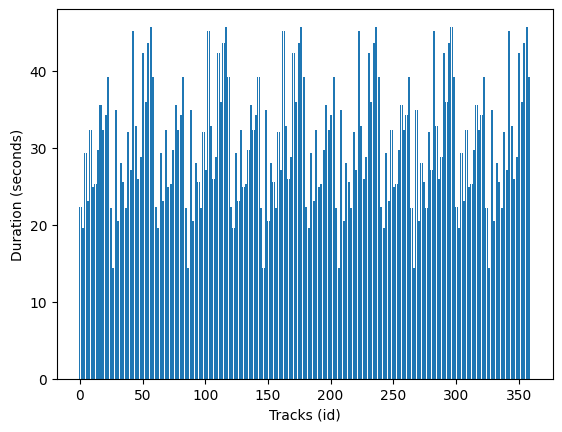

Mean:	30.47 seconds
Max:	45.71 seconds
Min:	14.40 seconds


In [11]:
# plotting duration information
duration_y = np.array(list(track_duration_map.values()))
duration_x = np.arange(len(duration_y))
plt.bar(duration_x, duration_y)
plt.xlabel("Tracks (id)")
plt.ylabel("Duration (seconds)")
plt.show()

print(f"Mean:\t{duration_y.mean():.2f} seconds")
print(f"Max:\t{duration_y.max():.2f} seconds")
print(f"Min:\t{duration_y.min():.2f} seconds")

In [40]:
# Does the annotation end match audio end?
mismatch_map = {}
for id, track in tracks.items():
    actual = librosa.get_duration(path=track.audio_mic_path)
    expected = track_duration_map[id]
    mismatch_map[id] = abs(expected - actual)

    if not np.isclose(actual, expected):
        print("Difference in Duration!")
        print(f"actual: {actual}\texpected: {expected}")

# analyze the difference
diff_array = np.array(list(mismatch_map.values()))
print("Difference Analysis:")
print(f"Mean: {diff_array.mean()} seconds")
print(f"Max: {diff_array.max()} seconds")
print(f"Min: {diff_array.min()} seconds")

Difference Analysis:
Mean: 4.293272864508424e-06 seconds
Max: 1.0884353741857922e-05 seconds
Min: 3.552713678800501e-15 seconds


### Findings
* Lead-sheet labels: continuous, full-coverage, no internal gaps, last-annotation-end matches audio-end to ~µs, no N present in practice → every frame gets a real chord; frame labeling is straightforward
* Labels are Harte-format root:quality strings, with intervals as [start, end] pairs ready for the [start, end) alignment logic